In [4]:
import boto3
import pandas as pd
import io
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import boto3
import io
import time

athena = boto3.client('athena')
s3 = boto3.client('s3')

# SQL - TOP 1000 liczników (największe zużycie)
response = athena.start_query_execution(
    QueryString='''
    SELECT 
        'MAC000002' as meter,
        COUNT(*) as measurements,
        AVG(MAC000002) as avg_consumption,
        MAX(MAC000002) as peak,
        MIN(MAC000002) as min_val,
        STDDEV(MAC000002) as std_dev
    FROM lcl_2013
    WHERE MAC000002 IS NOT NULL
    UNION ALL
    SELECT 
        'MAC000003' as meter,
        COUNT(*),
        AVG(MAC000003),
        MAX(MAC000003),
        MIN(MAC000003),
        STDDEV(MAC000003)
    FROM lcl_2013
    WHERE MAC000003 IS NOT NULL
    UNION ALL
    SELECT 
        'MAC000004' as meter,
        COUNT(*),
        AVG(MAC000004),
        MAX(MAC000004),
        MIN(MAC000004),
        STDDEV(MAC000004)
    FROM lcl_2013
    WHERE MAC000004 IS NOT NULL
    ORDER BY avg_consumption DESC
    LIMIT 1000
    ''',
    QueryExecutionContext={'Database': 'energy_db'},
    ResultConfiguration={'OutputLocation': 's3://londonss/athena-results/'}
)

query_id = response['QueryExecutionId']
print(f"Query ID: {query_id}")

# Czekaj
for i in range(60):
    resp = athena.get_query_execution(QueryExecutionId=query_id)
    status = resp['QueryExecution']['Status']['State']
    
    if status == 'SUCCEEDED':
        print("✓ Query wykonany!")
        break
    time.sleep(1)

# Pobierz wyniki
result_key = f"athena-results/{query_id}.csv"
resp = s3.get_object(Bucket='londonss', Key=result_key)
meters_stats = pd.read_csv(io.BytesIO(resp['Body'].read()))

print("\nTop 1000 liczników:")
print(meters_stats)

Query ID: 70b772fb-2064-4732-b921-c1b782a5acee
✓ Query wykonany!

Top 1000 liczników:
       meter  measurements  avg_consumption   peak  min_val   std_dev
0  MAC000003         17518         0.400065  3.757    0.007  0.639823
1  MAC000002         17520         0.240578  2.994    0.065  0.239675
2  MAC000004         17519         0.035290  0.690    0.000  0.071773


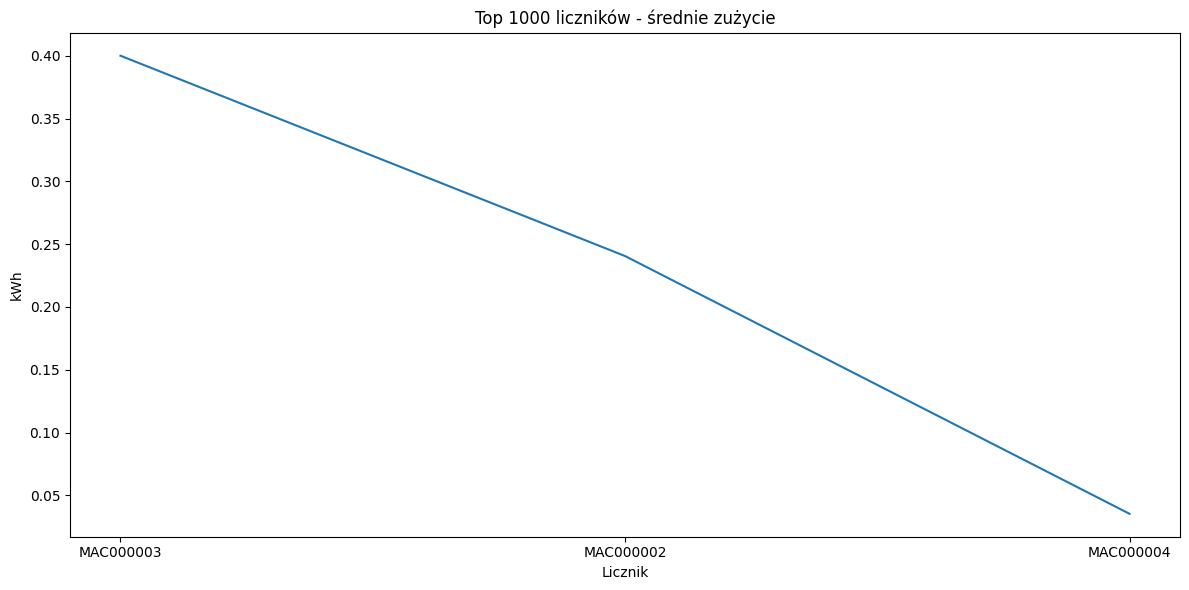

In [6]:
# Wizualizacja
plt.figure(figsize=(12, 6))
plt.plot(meters_stats['meter'], meters_stats['avg_consumption'])
plt.title('Top 1000 liczników - średnie zużycie')
plt.xlabel('Licznik')
plt.ylabel('kWh')
plt.tight_layout()

# Zapisz w folderze visualisations
plt.savefig('visualisations/top_1000_meters.png', dpi=100)
plt.show()

In [7]:
import pandas as pd
import os

# Wczytaj plik
file_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\08_AWS_proj\data\raw\LCL_2013.csv"
df = pd.read_csv(file_path)

print(f"Dane wczytane: {df.shape}")
print(f"Liczniki: {df.shape[1] - 1}")  # -1 na DateTime
print(f"\nPierwsze kolumny:")
print(df.columns[:10])

Dane wczytane: (17520, 4444)
Liczniki: 4443

Pierwsze kolumny:
Index(['DateTime', 'MAC000002', 'MAC000003', 'MAC000004', 'MAC000006',
       'MAC000007', 'MAC000008', 'MAC000009', 'MAC000010', 'MAC000011'],
      dtype='object')


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('visualisations', exist_ok=True)

# Wczytaj plik
file_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\08_AWS_proj\data\raw\LCL_2013.csv"
df = pd.read_csv(file_path)

# Przygotuj dane
df['DateTime'] = pd.to_datetime(df['DateTime'])
meters = df.columns[1:]  # Wszystkie kolumny oprócz DateTime

print(f"Analizuję {len(meters)} liczników...\n")

# === STATYSTYKA ===
print("1. STATYSTYKA OGÓLNA:")
print(f"   Łączna liczba pomiarów: {len(df)}")
print(f"   Zakres czasowy: {df['DateTime'].min()} do {df['DateTime'].max()}")

# 2. Zużycie na licznik
print("\n2. ZUŻYCIE NA LICZNIK:")
total_consumption = df[meters].sum()
avg_consumption = df[meters].mean()

print(f"   Średnie zużycie na licznik: {avg_consumption.mean():.4f} kWh")
print(f"   Max licznik: {total_consumption.idxmax()} = {total_consumption.max():.0f} kWh")
print(f"   Min licznik: {total_consumption.idxmin()} = {total_consumption.min():.0f} kWh")

# 3. TOP 20 konsumentów
print("\n3. TOP 20 LICZNIKÓW (łączne zużycie):")
top_20 = total_consumption.nlargest(20)
for i, (meter, consumption) in enumerate(top_20.items(), 1):
    print(f"   {i}. {meter}: {consumption:.0f} kWh")

# 4. Brakujące dane
print("\n4. BRAKUJĄCE DANE:")
missing_pct = (df[meters].isnull().sum() / len(df)) * 100
meters_with_missing = missing_pct[missing_pct > 0]
print(f"   Liczniki z brakami: {len(meters_with_missing)}")
print(f"   Średni % braków: {missing_pct.mean():.2f}%")

# 5. Rozkład zużycia
print("\n5. ROZKŁAD ZUŻYCIA:")
print(f"   Średnia: {df[meters].mean().mean():.4f} kWh")
print(f"   Mediana: {df[meters].median().mean():.4f} kWh")
print(f"   Std Dev: {df[meters].std().mean():.4f} kWh")

# === WIZUALIZACJE ===
print("\nTworzę wizualizacje...")

# Wykres 1: TOP 20 liczników
fig, ax = plt.subplots(figsize=(12, 6))
top_20.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Łączne zużycie (kWh)')
ax.set_title('TOP 20 liczników - łączne zużycie energii')
plt.tight_layout()
plt.savefig('visualisations/top_20_meters.png', dpi=100)
plt.close()
print("✓ top_20_meters.png")

# Wykres 2: Rozkład zużycia
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(total_consumption, bins=50, edgecolor='black', color='coral')
ax.set_xlabel('Łączne zużycie (kWh)')
ax.set_ylabel('Liczba liczników')
ax.set_title('Rozkład zużycia energii - wszyscy liczniki')
plt.tight_layout()
plt.savefig('visualisations/consumption_distribution.png', dpi=100)
plt.close()
print("✓ consumption_distribution.png")

# Wykres 3: Brakujące dane
fig, ax = plt.subplots(figsize=(12, 6))
missing_counts = df[meters].isnull().sum()
ax.hist(missing_counts, bins=50, edgecolor='black', color='red', alpha=0.7)
ax.set_xlabel('Liczba brakujących wartości')
ax.set_ylabel('Liczba liczników')
ax.set_title('Rozkład brakujących danych')
plt.tight_layout()
plt.savefig('visualisations/missing_data_distribution.png', dpi=100)
plt.close()
print("✓ missing_data_distribution.png")

print("\n" + "="*60)
print("✓ EDA ZAKOŃCZONA!")
print("="*60)

Analizuję 4443 liczników...

1. STATYSTYKA OGÓLNA:
   Łączna liczba pomiarów: 17520
   Zakres czasowy: 2013-01-01 00:30:00 do 2014-01-01 00:00:00

2. ZUŻYCIE NA LICZNIK:
   Średnie zużycie na licznik: 0.2154 kWh
   Max licznik: MAC004179 = 36994 kWh
   Min licznik: MAC000393 = 0 kWh

3. TOP 20 LICZNIKÓW (łączne zużycie):
   1. MAC004179: 36994 kWh
   2. MAC005406: 29918 kWh
   3. MAC003329: 24780 kWh
   4. MAC001145: 24358 kWh
   5. MAC003507: 23025 kWh
   6. MAC000557: 22523 kWh
   7. MAC001315: 22142 kWh
   8. MAC001739: 21669 kWh
   9. MAC002213: 20617 kWh
   10. MAC001198: 20087 kWh
   11. MAC002627: 19859 kWh
   12. MAC001735: 19742 kWh
   13. MAC002872: 18992 kWh
   14. MAC004319: 18573 kWh
   15. MAC000105: 18510 kWh
   16. MAC002628: 17921 kWh
   17. MAC004409: 17345 kWh
   18. MAC003979: 16846 kWh
   19. MAC002849: 16839 kWh
   20. MAC002441: 16617 kWh

4. BRAKUJĄCE DANE:
   Liczniki z brakami: 3562
   Średni % braków: 4.75%

5. ROZKŁAD ZUŻYCIA:
   Średnia: 0.2154 kWh
   Media

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('visualisations', exist_ok=True)

# Wczytaj plik
file_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\08_AWS_proj\data\raw\LCL_2013.csv"
df = pd.read_csv(file_path)

df['DateTime'] = pd.to_datetime(df['DateTime'])
meters = df.columns[1:]

# === SEGMENTACJA ===
print("SEGMENTACJA LICZNIKÓW\n")
print("="*60)

# Oblicz metryki dla każdego licznika
meter_stats = pd.DataFrame({
    'meter': meters,
    'total_consumption': df[meters].sum().values,
    'avg_consumption': df[meters].mean().values,
    'std_dev': df[meters].std().values,
    'peak': df[meters].max().values,
    'missing_pct': (df[meters].isnull().sum() / len(df) * 100).values
})

# Filtruj liczniki z dużą ilością braków
meter_stats_clean = meter_stats[meter_stats['missing_pct'] < 20].copy()

print(f"Liczniki (przed filtrem): {len(meter_stats)}")
print(f"Liczniki (po usunięciu >20% braków): {len(meter_stats_clean)}")

# Segmentacja na podstawie zużycia
# Użyj percentyli
p33 = meter_stats_clean['total_consumption'].quantile(0.33)
p66 = meter_stats_clean['total_consumption'].quantile(0.66)

def segment_meter(consumption):
    if consumption == 0:
        return 'Inactive'
    elif consumption < p33:
        return 'Residential'
    elif consumption < p66:
        return 'Commercial'
    else:
        return 'Industrial'

meter_stats_clean['segment'] = meter_stats_clean['total_consumption'].apply(segment_meter)

# Statystyka segmentów
print("\n1. PODZIAŁ NA SEGMENTY:")
segment_counts = meter_stats_clean['segment'].value_counts()
for segment, count in segment_counts.items():
    pct = count / len(meter_stats_clean) * 100
    print(f"   {segment}: {count} ({pct:.1f}%)")

# Zużycie po segmentach
print("\n2. ŚREDNIE ZUŻYCIE NA SEGMENT:")
segment_consumption = meter_stats_clean.groupby('segment')['total_consumption'].agg(['mean', 'sum', 'count'])
print(segment_consumption)

# Volatility (std_dev / mean) - jak zmiienne są dane
print("\n3. VOLATILITY (zmienność):")
meter_stats_clean['volatility'] = meter_stats_clean['std_dev'] / (meter_stats_clean['avg_consumption'] + 0.001)
volatility_by_segment = meter_stats_clean.groupby('segment')['volatility'].mean()
print(volatility_by_segment)

# === WIZUALIZACJE ===
print("\nTworzę wizualizacje...")

# Wykres 1: Liczba liczników po segmentach
fig, ax = plt.subplots(figsize=(10, 6))
segment_counts.plot(kind='bar', ax=ax, color=['green', 'orange', 'red', 'darkred'])
ax.set_ylabel('Liczba liczników')
ax.set_title('Segmentacja liczników - rozkład')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('visualisations/segmentation_count.png', dpi=100)
plt.close()
print("✓ segmentation_count.png")

# Wykres 2: Średnie zużycie po segmentach
fig, ax = plt.subplots(figsize=(10, 6))
segment_consumption['mean'].plot(kind='bar', ax=ax, color=['green', 'orange', 'red', 'darkred'])
ax.set_ylabel('Średnie zużycie (kWh)')
ax.set_title('Średnie zużycie energii po segmentach')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('visualisations/segmentation_consumption.png', dpi=100)
plt.close()
print("✓ segmentation_consumption.png")

# Wykres 3: Box plot - rozkład zużycia po segmentach
fig, ax = plt.subplots(figsize=(10, 6))
meter_stats_clean.boxplot(column='total_consumption', by='segment', ax=ax)
ax.set_ylabel('Łączne zużycie (kWh)')
ax.set_xlabel('Segment')
ax.set_title('Rozkład zużycia po segmentach')
plt.tight_layout()
plt.savefig('visualisations/segmentation_boxplot.png', dpi=100)
plt.close()
print("✓ segmentation_boxplot.png")

# Zapisz dane dla dashboard'u
meter_stats_clean.to_csv('data/meter_segmentation.csv', index=False)
print("\n✓ meter_segmentation.csv")

print("\n" + "="*60)
print("✓ SEGMENTACJA ZAKOŃCZONA!")
print("="*60)

SEGMENTACJA LICZNIKÓW

Liczniki (przed filtrem): 4443
Liczniki (po usunięciu >20% braków): 4138

1. PODZIAŁ NA SEGMENTY:
   Industrial: 1407 (34.0%)
   Commercial: 1365 (33.0%)
   Residential: 1364 (33.0%)
   Inactive: 2 (0.0%)

2. ŚREDNIE ZUŻYCIE NA SEGMENT:
                    mean           sum  count
segment                                      
Commercial   3099.137893  4.230323e+06   1365
Inactive        0.000000  0.000000e+00      2
Industrial   6477.606993  9.113993e+06   1407
Residential  1548.888228  2.112684e+06   1364

3. VOLATILITY (zmienność):
segment
Commercial     1.015410
Inactive       0.000000
Industrial     0.955023
Residential    1.191662
Name: volatility, dtype: float64

Tworzę wizualizacje...
✓ segmentation_count.png
✓ segmentation_consumption.png
✓ segmentation_boxplot.png

✓ meter_segmentation.csv

✓ SEGMENTACJA ZAKOŃCZONA!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')
import os

os.makedirs('visualisations', exist_ok=True)

# Wczytaj dane
file_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\08_AWS_proj\data\raw\LCL_2013.csv"
df = pd.read_csv(file_path)
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Wczytaj segmentację
meter_stats = pd.read_csv('data/meter_segmentation.csv')

# Wybierz najlepszego reprezentanta z każdego segmentu
representatives = {}
for segment in ['Residential', 'Commercial', 'Industrial']:
    segment_meters = meter_stats[meter_stats['segment'] == segment]
    best_meter = segment_meters.loc[segment_meters['total_consumption'].idxmax(), 'meter']
    representatives[segment] = best_meter
    print(f"{segment}: {best_meter}")

# === ANALIZA SZEREGÓW CZASOWYCH ===
print("\n" + "="*60)
print("TIME SERIES ANALYSIS")
print("="*60)

for segment, meter in representatives.items():
    print(f"\n{segment.upper()} ({meter}):")
    print("-" * 40)
    
    # Przygotuj dane
    daily = df[['DateTime', meter]].copy()
    daily.columns = ['DateTime', 'consumption']
    daily['DateTime'] = pd.to_datetime(daily['DateTime'])
    daily = daily.set_index('DateTime')
    daily = daily.resample('D').mean()
    daily = daily.dropna()
    
    print(f"  Dni: {len(daily)}")
    print(f"  Średnia: {daily['consumption'].mean():.2f} kWh")
    print(f"  Peak: {daily['consumption'].max():.2f} kWh")
    
    # Decomposition
    if len(daily) >= 30:
        decomposition = seasonal_decompose(daily['consumption'], model='additive', period=7)
        
        # Trend direction
        trend_start = decomposition.trend.iloc[:30].mean()
        trend_end = decomposition.trend.iloc[-30:].mean()
        trend_direction = "↑ Rosnący" if trend_end > trend_start else "↓ Malejący"
        print(f"  Trend: {trend_direction}")
        
        # Sezonowość
        seasonal_amplitude = decomposition.seasonal.max() - decomposition.seasonal.min()
        print(f"  Sezonowość (amplitude): {seasonal_amplitude:.2f} kWh")
    
    # Forecast z Prophet
    train_data = pd.DataFrame({
        'ds': daily.index,
        'y': daily['consumption'].values
    })
    
    train_size = int(len(train_data) * 0.8)
    train = train_data[:train_size]
    test = train_data[train_size:]
    
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(train)
    
    future = pd.DataFrame({'ds': test['ds']})
    forecast = model.predict(future)
    
    # Accuracy
    from sklearn.metrics import mean_absolute_error
    mae = mean_absolute_error(test['y'], forecast['yhat'])
    print(f"  Forecast MAE: {mae:.4f}")

print("\n✓ TIME SERIES ANALYSIS ZAKOŃCZONA!")

Importing plotly failed. Interactive plots will not work.


Residential: MAC003008
Commercial: MAC004186
Industrial: MAC004179

TIME SERIES ANALYSIS

RESIDENTIAL (MAC003008):
----------------------------------------
  Dni: 366
  Średnia: 0.13 kWh
  Peak: 0.19 kWh
  Trend: ↑ Rosnący
  Sezonowość (amplitude): 0.01 kWh


13:22:48 - cmdstanpy - INFO - Chain [1] start processing
13:22:49 - cmdstanpy - INFO - Chain [1] done processing
13:22:50 - cmdstanpy - INFO - Chain [1] start processing
13:22:50 - cmdstanpy - INFO - Chain [1] done processing


  Forecast MAE: 0.0360

COMMERCIAL (MAC004186):
----------------------------------------
  Dni: 366
  Średnia: 0.23 kWh
  Peak: 0.31 kWh
  Trend: ↓ Malejący
  Sezonowość (amplitude): 0.03 kWh


13:22:50 - cmdstanpy - INFO - Chain [1] start processing


  Forecast MAE: 0.0702

INDUSTRIAL (MAC004179):
----------------------------------------
  Dni: 366
  Średnia: 2.11 kWh
  Peak: 5.79 kWh
  Trend: ↑ Rosnący
  Sezonowość (amplitude): 0.28 kWh


13:22:51 - cmdstanpy - INFO - Chain [1] done processing


  Forecast MAE: 0.4946

✓ TIME SERIES ANALYSIS ZAKOŃCZONA!


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

os.makedirs('visualisations', exist_ok=True)

# Wczytaj dane
file_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\08_AWS_proj\data\raw\LCL_2013.csv"
df = pd.read_csv(file_path)
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Wczytaj segmentację
meter_stats = pd.read_csv('data/meter_segmentation.csv')

# Wybierz Industrial meter
industrial_meter = 'MAC004179'

print("ANOMALY DETECTION")
print("="*60)
print(f"Meter: {industrial_meter}\n")

# Przygotuj dane dziennie
daily = df[['DateTime', industrial_meter]].copy()
daily.columns = ['DateTime', 'consumption']
daily['date'] = daily['DateTime'].dt.date
daily_agg = daily.groupby('date')['consumption'].sum().reset_index()
daily_agg.columns = ['date', 'consumption']

# Metoda 1: Z-score (powyżej 2.5 std = anomalia)
z_scores = np.abs(stats.zscore(daily_agg['consumption']))
anomalies_zscore = daily_agg[z_scores > 2.5].copy()

print("1. ANOMALIE - Z-SCORE METHOD (>2.5 std):")
print(f"   Liczba anomalii: {len(anomalies_zscore)}")
if len(anomalies_zscore) > 0:
    print("   Top anomalii:")
    for idx, row in anomalies_zscore.nlargest(5, 'consumption').iterrows():
        print(f"   - {row['date']}: {row['consumption']:.1f} kWh")

# Metoda 2: IQR (Interquartile Range)
Q1 = daily_agg['consumption'].quantile(0.25)
Q3 = daily_agg['consumption'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies_iqr = daily_agg[(daily_agg['consumption'] < lower_bound) | (daily_agg['consumption'] > upper_bound)].copy()

print(f"\n2. ANOMALIE - IQR METHOD:")
print(f"   Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"   Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"   Liczba anomalii: {len(anomalies_iqr)}")
if len(anomalies_iqr) > 0:
    print("   Top anomalii:")
    for idx, row in anomalies_iqr.nlargest(5, 'consumption').iterrows():
        print(f"   - {row['date']}: {row['consumption']:.1f} kWh")

# === WIZUALIZACJA ===
print(f"\nTworzę wizualizacje...")

fig, ax = plt.subplots(figsize=(14, 6))

# Linia podstawowa
ax.plot(daily_agg['date'], daily_agg['consumption'], linewidth=2, label='Daily Consumption', color='steelblue')

# Anomalie
if len(anomalies_iqr) > 0:
    ax.scatter(anomalies_iqr['date'], anomalies_iqr['consumption'], 
              color='red', s=100, marker='o', label='Anomalies', zorder=5)

# Bounds
ax.axhline(y=upper_bound, color='orange', linestyle='--', alpha=0.7, label='Upper Bound')
ax.axhline(y=lower_bound, color='orange', linestyle='--', alpha=0.7, label='Lower Bound')
ax.axhline(y=daily_agg['consumption'].mean(), color='green', linestyle='--', alpha=0.5, label='Mean')

ax.set_xlabel('Date')
ax.set_ylabel('Consumption (kWh)')
ax.set_title(f'Anomaly Detection - {industrial_meter}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualisations/anomaly_detection.png', dpi=100)
plt.close()

print("✓ anomaly_detection.png")

# Zapisz anomalie
anomalies_iqr.to_csv('data/anomalies.csv', index=False)
print("✓ anomalies.csv")

print("\n" + "="*60)
print("✓ ANOMALY DETECTION ZAKOŃCZONA!")
print("="*60)

ANOMALY DETECTION
Meter: MAC004179

1. ANOMALIE - Z-SCORE METHOD (>2.5 std):
   Liczba anomalii: 7
   Top anomalii:
   - 2013-02-18: 278.0 kWh
   - 2013-11-13: 270.8 kWh
   - 2013-02-17: 234.4 kWh
   - 2013-11-14: 201.8 kWh
   - 2013-11-12: 191.8 kWh

2. ANOMALIE - IQR METHOD:
   Q1: 88.45, Q3: 109.70, IQR: 21.25
   Bounds: [56.57, 141.58]
   Liczba anomalii: 8
   Top anomalii:
   - 2013-02-18: 278.0 kWh
   - 2013-11-13: 270.8 kWh
   - 2013-02-17: 234.4 kWh
   - 2013-11-14: 201.8 kWh
   - 2013-11-12: 191.8 kWh

Tworzę wizualizacje...
✓ anomaly_detection.png
✓ anomalies.csv

✓ ANOMALY DETECTION ZAKOŃCZONA!
